# Plotting

## Objectives 

- Create a time series plot showing a single data set.
- Create a scatter plot showing relationship between two data sets.

## [`matplotlib`](https://matplotlib.org/) is the most widely used scientific plotting library in Python.

- Commonly use a sub-library called [`matplotlib.pyplot`](https://matplotlib.org/stable/tutorials/introductory/pyplot.html).
- The Jupyter Notebook will render plots inline by default.


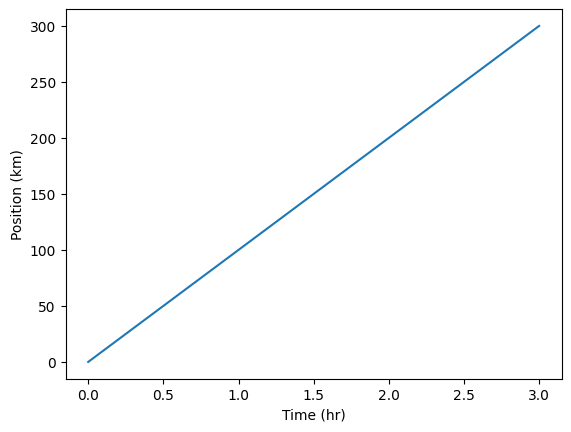

In [6]:
import matplotlib.pyplot as plt

time = [0, 1, 2, 3]
position = [0, 100, 200, 300]

plt.plot(time, position)
plt.xlabel('Time (hr)')
plt.ylabel('Position (km)')
plt.show()

## Plot data directly from a [`Pandas dataframe`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.html).

- We can also plot [Pandas dataframes](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.html).
- Before plotting, we convert the column headings from a `string` to `integer` data type, since they represent numerical values,
  using [str.replace()](https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html) to remove the `gpdPercap_`
  prefix and then [astype(int)](https://pandas.pydata.org/docs/reference/api/pandas.Series.astype.html)
  to convert the series of string values (`['1952', '1957', ..., '2007']`) to a series of integers: `[1925, 1957, ..., 2007]`.


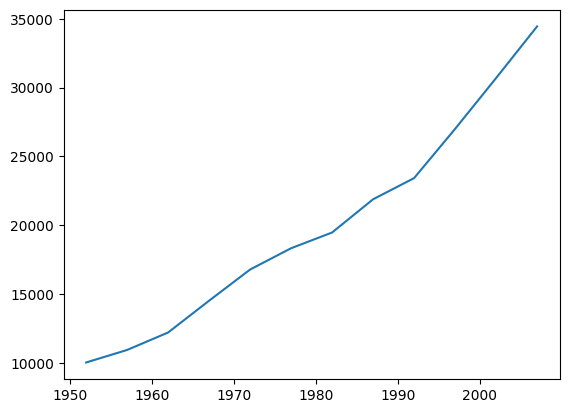

In [7]:
import pandas as pd

data = pd.read_csv('data/gapminder_gdp_oceania.csv', index_col='country')

# Extract year from last 4 characters of each column name
# The current column names are structured as 'gdpPercap_(year)', 
# so we want to keep the (year) part only for clarity when plotting GDP vs. years
# To do this we use replace(), which removes from the string the characters stated in the argument
# This method works on strings, so we use replace() from Pandas Series.str vectorized string functions

years = data.columns.str.replace('gdpPercap_', '')

# Convert year values to integers, saving results back to dataframe

data.columns = years.astype(int)

data.loc['Australia'].plot()
plt.show()

## Select and transform data, then plot it.

- By default, [`DataFrame.plot`](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.plot.html#pandas.DataFrame.plot) plots with the rows as the X axis.
- We can transpose the data in order to plot multiple series.



Text(0, 0.5, 'GDP per capita')

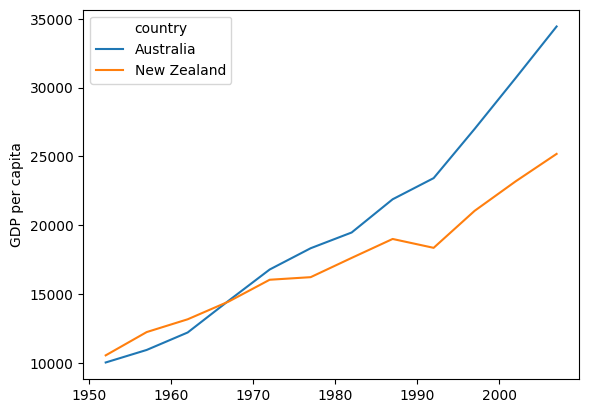

In [8]:
data.T.plot()
plt.ylabel('GDP per capita')

## Many styles of plot are available.

Text(0, 0.5, 'GDP per capita')

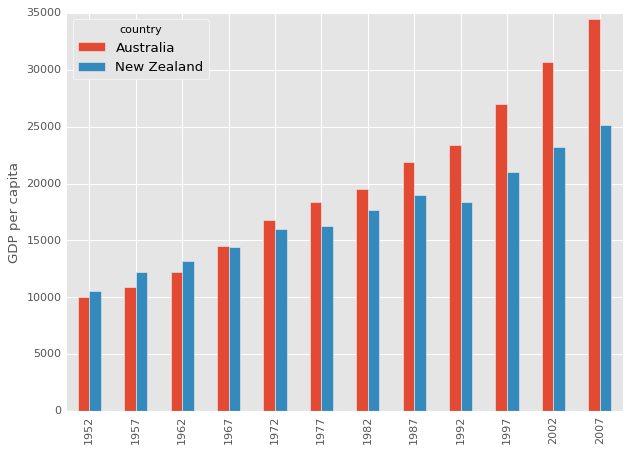

In [19]:
plt.style.use('ggplot')
data.T.plot(kind='bar')
plt.ylabel('GDP per capita')

In [13]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']


## Data can also be plotted by calling the `matplotlib` `plot` function directly.

- The command is `plt.plot(x, y)`
- The color and format of markers can also be specified as an additional optional argument e.g., `b-` is a blue line, `g--` is a green dashed line.

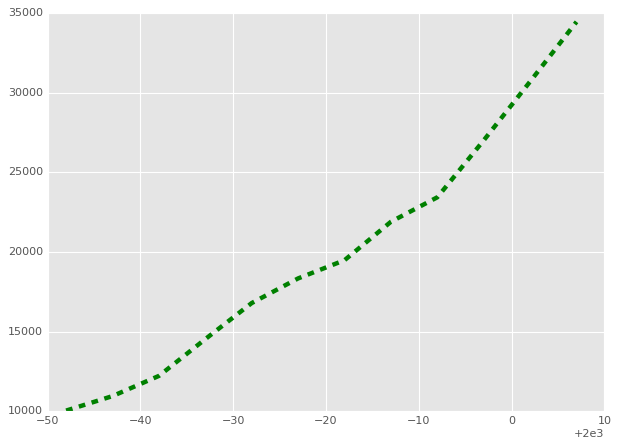

In [20]:
years = data.columns
gdp_australia = data.loc['Australia']

plt.plot(years, gdp_australia, 'g--')

## Can plot many sets of data together


Text(0, 0.5, 'GDP per capita ($)')

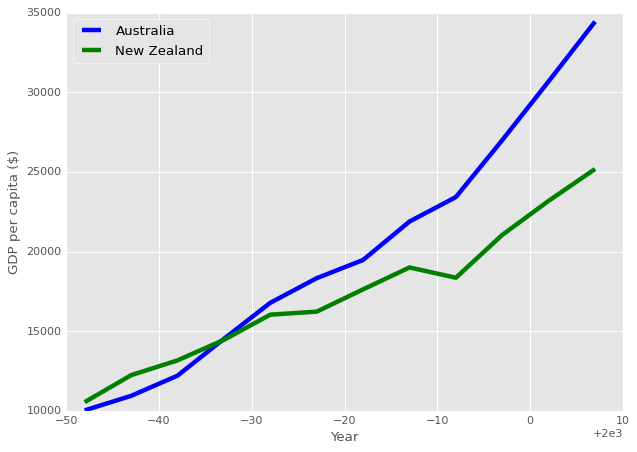

In [21]:
gdp_australia = data.loc['Australia']
gdp_nz = data.loc['New Zealand']

# Plot with differently-colored markers.
plt.plot(years, gdp_australia, 'b-', label='Australia')
plt.plot(years, gdp_nz, 'g-', label='New Zealand')

# Create legend.
plt.legend(loc='upper left')
plt.xlabel('Year')
plt.ylabel('GDP per capita ($)')


## Adding a Legend

This can be done in `matplotlib` in two stages:

- Provide a label for each dataset in the figure,
- Instruct `matplotlib` to create the legend.


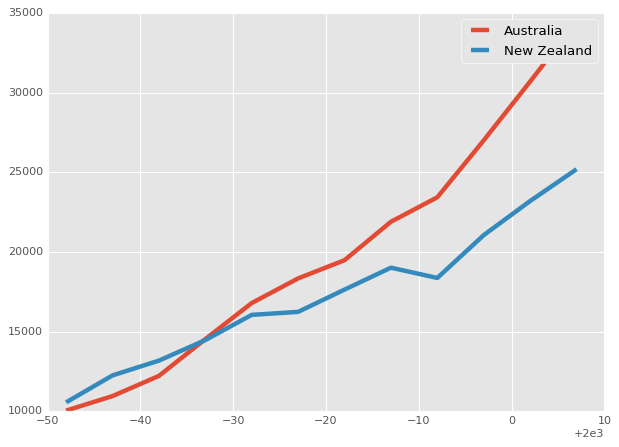

In [23]:
plt.plot(years, gdp_australia, label='Australia')
plt.plot(years, gdp_nz, label='New Zealand')
plt.legend()
plt.show()

- By default matplotlib will attempt to place the legend in a suitable position. If you
would rather specify a position this can be done with the `loc=` argument, e.g to place
the legend in the upper left corner of the plot, specify `loc='upper left'`

## Exercises

1. Fill in the blanks below to plot the minimum GDP per capita over time
for all the countries in Europe.
Modify it again to plot the maximum GDP per capita over time for Europe.

```python
data_europe = pd.read_csv('data/gapminder_gdp_europe.csv', index_col='country')
data_europe.____.plot(label='min')
data_europe.____
plt.legend(loc='best')
plt.xticks(rotation=90)
```

2. Modify the example in the notes to create a scatter plot showing
the relationship between the minimum and maximum GDP per capita
among the countries in Asia for each year in the data set.
What relationship do you see (if any)?


3. This short program creates a plot showing
the correlation between GDP and life expectancy for 2007,
normalizing marker size by population. Using online help and other resources,
explain what each argument to `plot` does.

```python
data_all = pd.read_csv('data/gapminder_all.csv', index_col='country')
data_all.plot(kind='scatter', x='gdpPercap_2007', y='lifeExp_2007', s=data_all['pop_2007']/1e6)
```


## Saving your plot to a file

If you are satisfied with the plot you see you may want to save it to a file,
perhaps to include it in a publication. There is a function in the
matplotlib.pyplot module that accomplishes this:
[savefig](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html).
Calling this function, e.g. with

```python
plt.savefig('my_figure.png')
```

When using dataframes, data is often generated and plotted to screen in one line.
In addition to using `plt.savefig`, we can save a reference to the current figure
in a local variable (with `plt.gcf`) and call the `savefig` class method from
that variable to save the figure to file.

```python
data.plot(kind='bar')
fig = plt.gcf() # get current figure
fig.savefig('my_figure.png')
```


## Making your plots accessible

Whenever you are generating plots to go into a paper or a presentation, there are a few things you can do to make sure that everyone can understand your plots.

- Always make sure your text is large enough to read. Use the `fontsize` parameter in `xlabel`, `ylabel`, `title`, and `legend`, and [`tick_params` with `labelsize`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html) to increase the text size of the numbers on your axes.
- Similarly, you should make your graph elements easy to see. Use `s` to increase the size of your scatterplot markers and `linewidth` to increase the sizes of your plot lines.
- Using color (and nothing else) to distinguish between different plot elements will make your plots unreadable to anyone who is colorblind, or who happens to have a black-and-white office printer. For lines, the `linestyle` parameter lets you use different types of lines. For scatterplots, `marker` lets you change the shape of your points. If you're unsure about your colors, you can use [Coblis](https://www.color-blindness.com/coblis-color-blindness-simulator/) or [Color Oracle](https://colororacle.org/) to simulate what your plots would look like to those with colorblindness.

## Takeaway
- [`matplotlib`](https://matplotlib.org/) is the most widely used scientific plotting library in Python.
- Plot data directly from a Pandas dataframe.
- Select and transform data, then plot it.
- Many styles of plot are available: see the [Python Graph Gallery](https://python-graph-gallery.com/matplotlib/) for more options.
- Can plot many sets of data together.

## Continue

1. [Introduction](./intro,html)
2. [Variables in Python](./variables.html)
3. [Libraries](./libraries.html)
4. [Tabular data](./tabular_data.html)
5. [**Plotting**](./plotting)